## Fase 1: Carga de Datos, Exploración Inicial y Tratamiento de Valores Faltantes

### 1. Configuración y Carga

In [1]:
# Importación de librerías esenciales para manipulación de datos
import pandas as pd

# Importación de librerías para visualización narrativa
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de herramientas de scikit-learn permitidas para imputación
from sklearn.impute import SimpleImputer

# Configuración del estilo visual de seaborn para los gráficos
sns.set_theme(style="whitegrid", palette="muted")

# Carga de datos cumpliendo el Guardrail G001: no alterar el archivo original
df_titanic = pd.read_csv('Titanic-Dataset.csv')

# Exploración inicial mostrando los primeros registros
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2. Análisis Exploratorio Inicial (EDA)

/tmp/ipykernel_17444/3000780611.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
/tmp/ipykernel_17444/3000780611.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


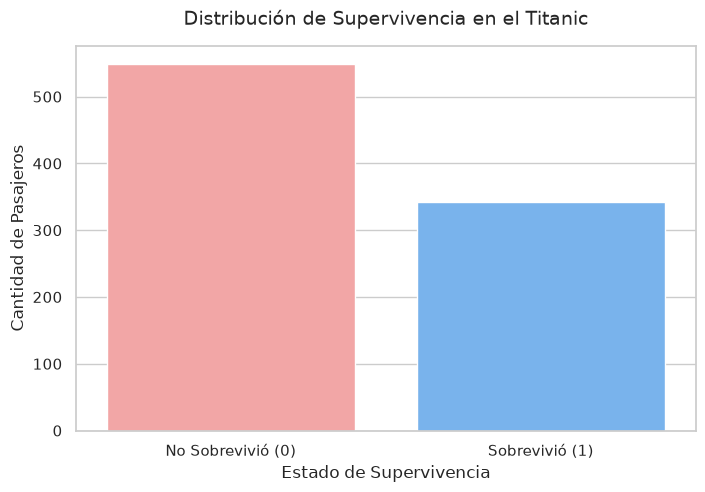

In [2]:
# Gráfico 1 de 15: Distribución de Supervivencia General
plt.figure(figsize=(8, 5))
# Contamos cuántos sobrevivieron y cuántos no
ax = sns.countplot(data=df_titanic, x='Survived', palette=['#ff9999','#66b3ff'])
# Renombramos los ejes para un mejor storytelling
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Distribución de Supervivencia en el Titanic', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.show()

### Interpretación:

/tmp/ipykernel_17444/6067645.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


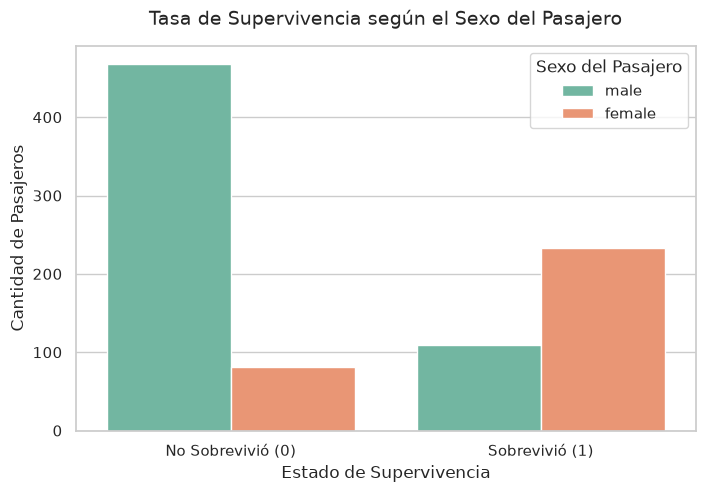

In [3]:
# Gráfico 2 de 15: Supervivencia Segmentada por Sexo
plt.figure(figsize=(8, 5))
# Evaluamos el impacto del género en la supervivencia
ax = sns.countplot(data=df_titanic, x='Survived', hue='Sex', palette='Set2')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según el Sexo del Pasajero', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Sexo del Pasajero')
plt.show()

### Interpretación:

/tmp/ipykernel_17444/1588591426.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])


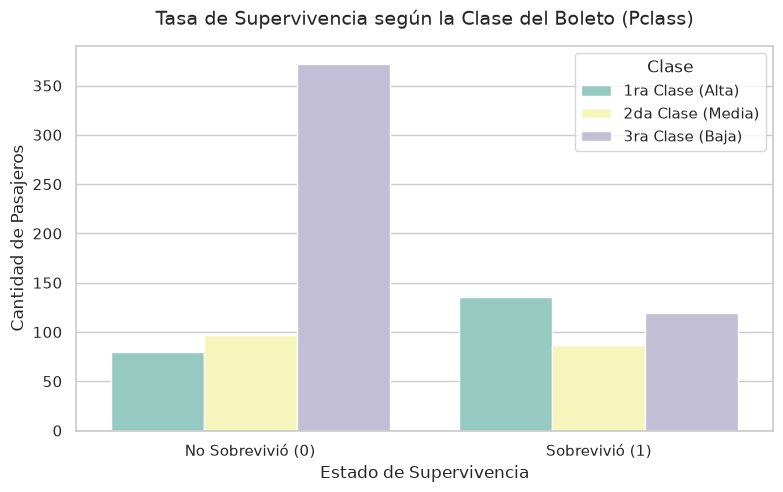

In [4]:
# Gráfico 3 de 15: Supervivencia Segmentada por Clase Económica
plt.figure(figsize=(9, 5))
# Mostramos cómo la clase del boleto influyó en el rescate
ax = sns.countplot(data=df_titanic, x='Survived', hue='Pclass', palette='Set3')
ax.set_xticklabels(['No Sobrevivió (0)', 'Sobrevivió (1)'])
plt.title('Tasa de Supervivencia según la Clase del Boleto (Pclass)', fontsize=14, pad=15)
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Clase', labels=['1ra Clase (Alta)', '2da Clase (Media)', '3ra Clase (Baja)'])
plt.show()

### Interpretación:

### 3. Diagnóstico y Tratamiento de Faltantes

Variables con valores nulos detectados:
 Age         177
Cabin       687
Embarked      2
dtype: int64


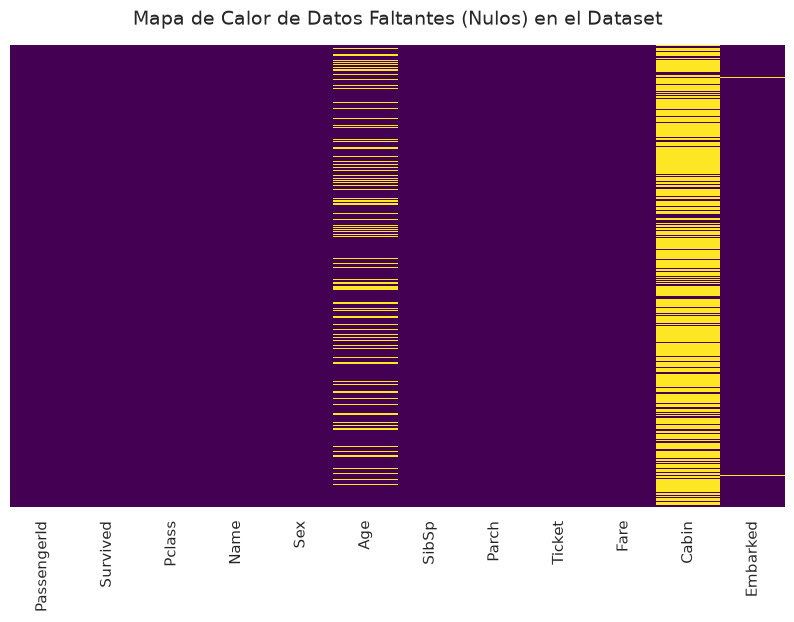

In [5]:
# Identificación inicial del volumen de datos nulos por atributo
nulos_por_columna = df_titanic.isnull().sum()
print("Variables con valores nulos detectados:\n", nulos_por_columna[nulos_por_columna > 0])

# Gráfico 4 de 15: Visualización de Vacíos (Heatmap de Nulos)
plt.figure(figsize=(10, 6))
# Mapeo visual donde las líneas amarillas representan datos faltantes
sns.heatmap(df_titanic.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes (Nulos) en el Dataset', fontsize=14, pad=15)
plt.show()

### Interpretación:

In [6]:
# Clonación del DataFrame original para realizar imputaciones sin perder el rastro de la fuente
df_clean = df_titanic.copy()

# Preservación de la columna Age original para una comparación estadística posterior
age_pre_imputacion = df_clean['Age'].copy()

### TRATAMIENTO DE FALTANTES ###

# 1. Tratamiento para 'Cabin'
# Justificación: Como vimos en el heatmap, la mayoría absoluta (>70%) de los datos de Cabin falta.
# Imputar tantos valores generaría un sesgo enorme e irreal. Por ello, es más seguro eliminar la columna entera.
df_clean.drop('Cabin', axis=1, inplace=True)

# 2. Tratamiento para 'Embarked'
# Justificación: Faltan solo 2 registros. Al ser categórica, la imputación por moda (el valor más común) 
# es estadísticamente segura y no altera la distribución.
imputador_moda = SimpleImputer(strategy='most_frequent')
df_clean['Embarked'] = imputador_moda.fit_transform(df_clean[['Embarked']]).ravel()

# 3. Tratamiento para 'Age'
# Justificación: La edad es crucial, pero falta aproximadamente un 20%. Al ser una distribución con ligera
# asimetría (sesgo por infantes), usamos la mediana en lugar de la media para mitigar el efecto de valores extremos.
imputador_mediana = SimpleImputer(strategy='median')
df_clean['Age'] = imputador_mediana.fit_transform(df_clean[['Age']]).ravel()

# Comprobación de que no queden datos nulos
print("Total de nulos restantes tras la Fase 1:", df_clean.isnull().sum().sum())

Total de nulos restantes tras la Fase 1: 0


### Interpretación:

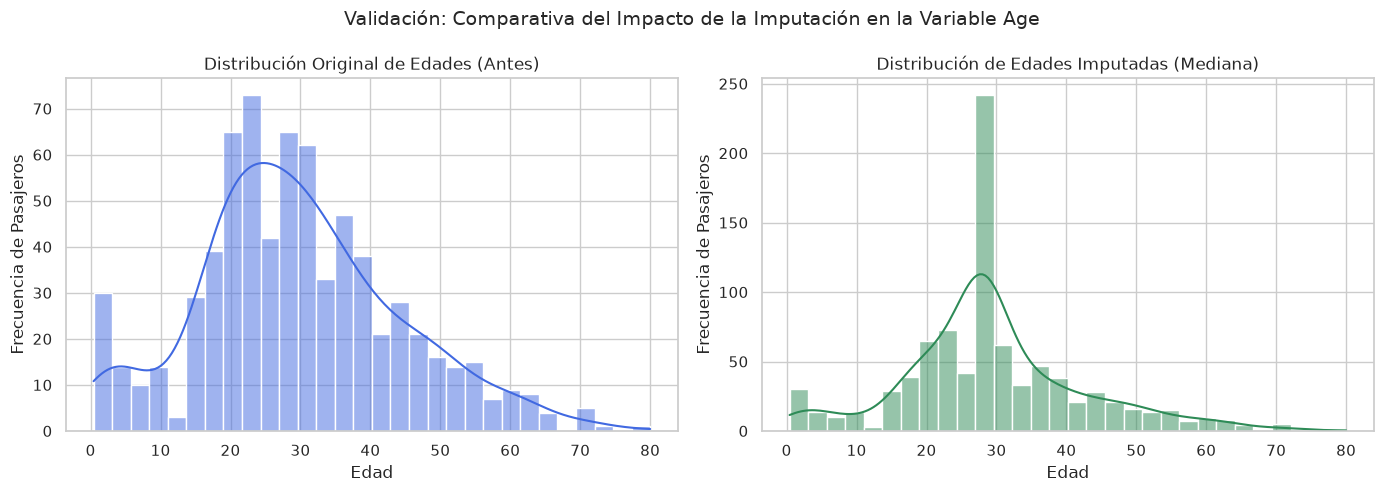

In [7]:
# Gráfico 5 de 15: Impacto de la imputación en la variable 'Age'
plt.figure(figsize=(14, 5))

# Gráfico de la distribución original (ignora nulos)
plt.subplot(1, 2, 1)
sns.histplot(age_pre_imputacion, kde=True, color='royalblue', bins=30)
plt.title('Distribución Original de Edades (Antes)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

# Gráfico de la distribución luego de la imputación por Mediana
plt.subplot(1, 2, 2)
sns.histplot(df_clean['Age'], kde=True, color='seagreen', bins=30)
plt.title('Distribución de Edades Imputadas (Mediana)', fontsize=12)
plt.xlabel('Edad')
plt.ylabel('Frecuencia de Pasajeros')

plt.suptitle('Validación: Comparativa del Impacto de la Imputación en la Variable Age', fontsize=14)
plt.tight_layout()
plt.show()

### Interpretación: